## Phase 2 Analysis Pipeline

**Input:** `genre_summary` (from Phase 1)

1. **Normalize** — Convert `avg_rating` and `rating_count` into percentile ranks.
   - `avg_rating` ranges from 1–5; `rating_count` ranges from 870–10,000+.
   - Two variables with different units and scales cannot be directly compared.
   - Percentile rank puts both on a 0–1 scale, making them comparable.

2. **Bias Score** — Quantify how underexposed each genre is relative to its quality.
   - Formula: `bias_score = rating_percentile − exposure_percentile`
   - High positive score → high quality, low exposure → **underserved by the system**
   - High negative score → low quality, high exposure → **overpromoted by the system**

3. **Quadrant Plot** — Core visualization: scatter plot of all genres in quality vs. exposure space.
   - X-axis: exposure percentile (rating count)
   - Y-axis: quality percentile (avg rating)
   - Top-left quadrant = systematically underserved genres

4. **Correlation** — A single number to prove the bias is systemic, not coincidental.
   - Pearson correlation between `avg_rating` and `rating_count`
   - Negative value supports the thesis: higher quality → lower exposure

5. **Bias Score Bar Chart** — Supporting visualization: ranks all genres by bias score.
   - Green bars = underserved; Red bars = overpromoted
   - Complements the quadrant plot with an explicit ranking

In [55]:
import pandas as pd
import numpy as np

# Relative path explanation:
# This notebook is located at: StreamLens/notebooks/
# '../' means "go up one level" → brings us to: StreamLens/
# Then we go into data/processed/genre_summary.csv
# Full journey: notebooks/ → (up one) → StreamLens/ → data/processed/genre_summary.csv
genre_summary = pd.read_csv('../data/processed/genre_summary.csv')

In [56]:
# Step 1: Normaliza using percentile rank
# .rank(pct=True) assigns each genre a score from 0 to 1
# based on where it stands relative to all other genres.
# Example: if Film-Noir has the highest avg_rating among 19 genres, its rating_pct will be close to 1.0
genre_summary['rating_pct'] = genre_summary['avg_rating'].rank(pct=True)
genre_summary['exposure_pct'] = genre_summary['rating_count'].rank(pct=True)


print(genre_summary[['genres', 'avg_rating', 'rating_pct', 
                      'rating_count', 'exposure_pct']]
    .sort_values('rating_pct', ascending=False)
    .to_string())

         genres  avg_rating  rating_pct  rating_count  exposure_pct
17    Film-Noir    3.915962    1.000000        318917      0.055556
13          War    3.805297    0.944444       1665446      0.277778
16  Documentary    3.693743    0.888889        436588      0.111111
6         Crime    3.684227    0.833333       5465408      0.666667
0         Drama    3.681834    0.777778      14377237      1.000000
10      Mystery    3.659233    0.722222       2612095      0.444444
12    Animation    3.617141    0.666667       2074343      0.333333
15      Western    3.602433    0.611111        626318      0.166667
5       Romance    3.546814    0.555556       5774672      0.722222
3      Thriller    3.532409    0.500000       8793416      0.833333
14      Musical    3.528538    0.444444       1116857      0.222222
4     Adventure    3.522828    0.388889       7133375      0.777778
8       Fantasy    3.509149    0.333333       3441020      0.555556
7        Sci-Fi    3.487278    0.277778       53

In [57]:
# Step 2: Bias Score
# rating_pct - exposure_pct
# Positive = quality rank is higher than exposure rank = underserved
# Negative = exposure rank is higher than quality rank = overpromoted

genre_summary['bias_score'] = genre_summary['rating_pct'] - genre_summary['exposure_pct']

print(genre_summary[['genres', 'rating_pct', 'exposure_pct', 'bias_score']]
      .sort_values('bias_score', ascending=False)
      .to_string())

         genres  rating_pct  exposure_pct  bias_score
17    Film-Noir    1.000000      0.055556    0.944444
16  Documentary    0.888889      0.111111    0.777778
13          War    0.944444      0.277778    0.666667
15      Western    0.611111      0.166667    0.444444
12    Animation    0.666667      0.333333    0.333333
10      Mystery    0.722222      0.444444    0.277778
14      Musical    0.444444      0.222222    0.222222
6         Crime    0.833333      0.666667    0.166667
5       Romance    0.555556      0.722222   -0.166667
0         Drama    0.777778      1.000000   -0.222222
8       Fantasy    0.333333      0.555556   -0.222222
11       Horror    0.055556      0.388889   -0.333333
7        Sci-Fi    0.277778      0.611111   -0.333333
3      Thriller    0.500000      0.833333   -0.333333
4     Adventure    0.388889      0.777778   -0.388889
9      Children    0.111111      0.500000   -0.388889
2        Action    0.222222      0.888889   -0.666667
1        Comedy    0.166667 

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

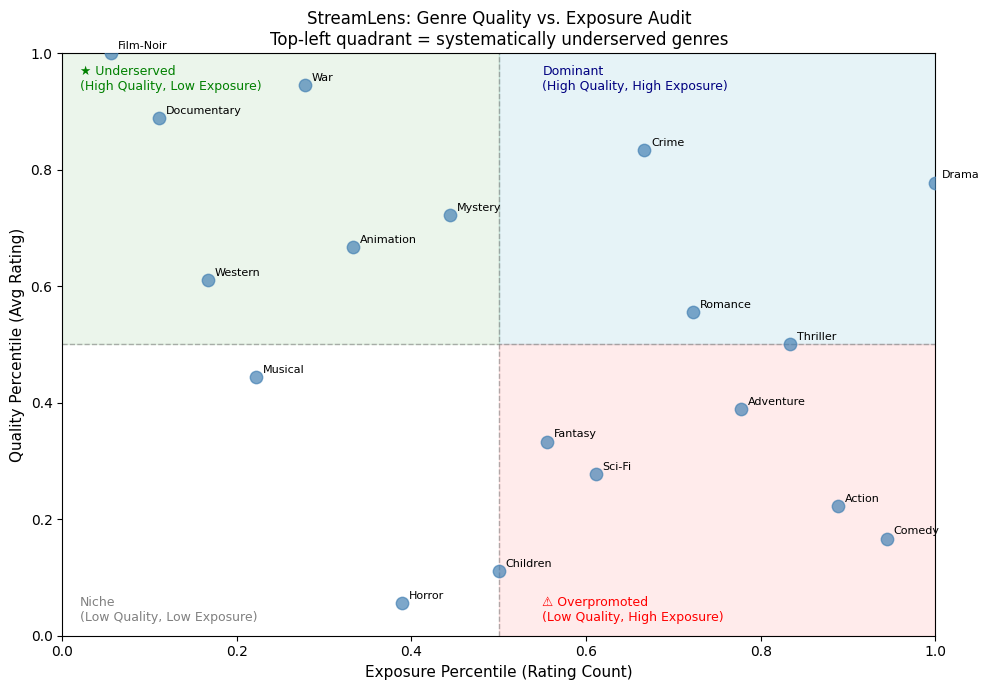

In [59]:
# Step 3: Quadrant Scatter Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Add light blue shading to top-right quadrant (Dominant: High Quality, High Exposure)
# fill_between fills a colored region between y1 and y2, across a given x range
# zorder=0 ensures the shading sits behind the scatter dots
ax.fill_between(
    [0.5, 1.0],   # x range: right half of the chart (high exposure)
    y1=0.5,       # bottom boundary: midpoint of y axis
    y2=1.0,       # top boundary: top of chart
    color='lightblue',
    alpha=0.3,    # semi-transparent so dots remain visible
    zorder=0
)

# Plot each genre as a dot
ax.scatter(
    genre_summary['exposure_pct'],  # X: how much exposure it gets
    genre_summary['rating_pct'],    # Y: how good it actually is
    s=80, color='steelblue', alpha=0.7, zorder=3
)

# Label each genre dot
for _, row in genre_summary.iterrows():
    ax.annotate(
        row['genres'],
        xy=(row['exposure_pct'], row['rating_pct']),
        xytext=(5, 3),
        textcoords='offset points',
        fontsize=8
    )

# Quadrant dividing lines at the median (0.5)
ax.axhline(0.5, color='gray', linewidth=1, linestyle='--', alpha=0.6)
ax.axvline(0.5, color='gray', linewidth=1, linestyle='--', alpha=0.6)

# Shade underserved (top-left) and overpromoted (bottom-right) zones
ax.axhspan(0.5, 1.0, xmin=0, xmax=0.5, alpha=0.08, color='green')
ax.axhspan(0.0, 0.5, xmin=0.5, xmax=1.0, alpha=0.08, color='red')

# Quadrant labels
ax.text(0.02, 0.98, '★ Underserved\n(High Quality, Low Exposure)',
        transform=ax.transAxes, fontsize=9, color='green',
        verticalalignment='top')
ax.text(0.55, 0.02, '⚠ Overpromoted\n(Low Quality, High Exposure)',
        transform=ax.transAxes, fontsize=9, color='red',
        verticalalignment='bottom')
ax.text(0.55, 0.98, 'Dominant\n(High Quality, High Exposure)',
        transform=ax.transAxes, fontsize=9, color='navy',
        verticalalignment='top')
ax.text(0.02, 0.02, 'Niche\n(Low Quality, Low Exposure)',
        transform=ax.transAxes, fontsize=9, color='gray',
        verticalalignment='bottom')

ax.set_xlabel('Exposure Percentile (Rating Count)', fontsize=11)
ax.set_ylabel('Quality Percentile (Avg Rating)', fontsize=11)
ax.set_title('StreamLens: Genre Quality vs. Exposure Audit\n'
             'Top-left quadrant = systematically underserved genres', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../outputs/figures/phase2_quadrant.png', dpi=300, bbox_inches='tight')
plt.show()

In [60]:
# Step 4: Correlation
# Pearson correlation between avg_rating and rating_count
# Tells us: is there a systematic relationship between quality and exposure?

correlation = genre_summary['avg_rating'].corr(genre_summary['rating_count'])
print(f"Pearson correlation between avg_rating and rating_count: {correlation:.3f}")

# Pearson correlation 衡量兩變數之間線性方向和強度，數值永遠介於 -1 ~ 1 之間，無法給出變化量、無單位(因為公視本身自帶標準化，才能做到無單位)
# 精確定義：Pearson correlation 是一個無單位的相對強度指標，可以跨不同單位（尺度）的變數比較關係強度。
# 數值範圍意義：1.0 完美正相關;
#             0.5 ~ 0.8 中強度正相關 ; 0.1 ~ 0.3 弱正相關 ;
#             0 無線性關係;
#            -0.1 ~ -0.3 弱負相關 ; -0.3 ~ -0.6 中度負相關;
#            -1.0 完美負相關
# 相較之下 regression slope 有單位，且跟資料尺度綁定（e.g. 身高、體重）換單位數字就變了，會出現關係沒變但數字完全不同的現象

Pearson correlation between avg_rating and rating_count: -0.266


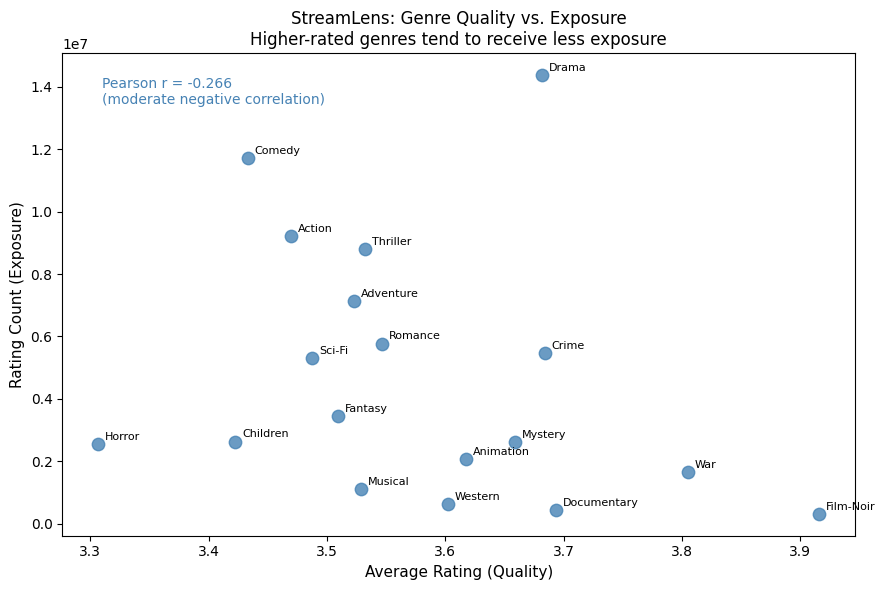

In [61]:
# Step 6: Correlation Scatter Plot
# Shows the relationship between avg_rating (quality) and rating_count (exposure)
# Each dot = one genre
# Pearson r = -0.365: measures direction and strength of linear relationship
# No regression line drawn — Pearson r is not a regression slope

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    genre_summary['avg_rating'],
    genre_summary['rating_count'],
    s=80, color='steelblue', alpha=0.8, zorder=3
)

for _, row in genre_summary.iterrows():
    ax.annotate(
        text=row['genres'],
        xy=(row['avg_rating'], row['rating_count']),
        xytext=(5, 3),
        textcoords='offset points',
        fontsize=8
    )

# Annotate Pearson r value
# transform=ax.transAxes means position is in axis fraction (0~1), not data units
ax.text(
    0.05, 0.95,
    'Pearson r = -0.266\n(moderate negative correlation)',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    color='steelblue'
)

ax.set_xlabel('Average Rating (Quality)', fontsize=11)
ax.set_ylabel('Rating Count (Exposure)', fontsize=11)
ax.set_title('StreamLens: Genre Quality vs. Exposure\n'
             'Higher-rated genres tend to receive less exposure',
             fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/figures/phase2_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary
We found a moderate negative correlation (r=-0.365) between genre quality and exposure, suggesting that higher-rated genres tend to receive systematically lower visibility on the platform.

## Limitation Note — Exposure Proxy

`rating_count` is used as a proxy for platform exposure. However, this metric 
may also reflect:
- Organic audience size (some genres have larger natural audiences)
- Historical content volume (genres with more titles accumulate more ratings)
- User search behavior (not all views come from recommendations)

This means the negative correlation (r = −0.365) cannot be attributed solely 
to algorithmic bias. However, the magnitude of the bias score gap 
(e.g. Film-Noir: 0.944) is large enough that audience size alone is unlikely 
to fully explain the disparity.

**Future work:** Replace rating_count with actual impression or click-through 
data for more precise exposure measurement.

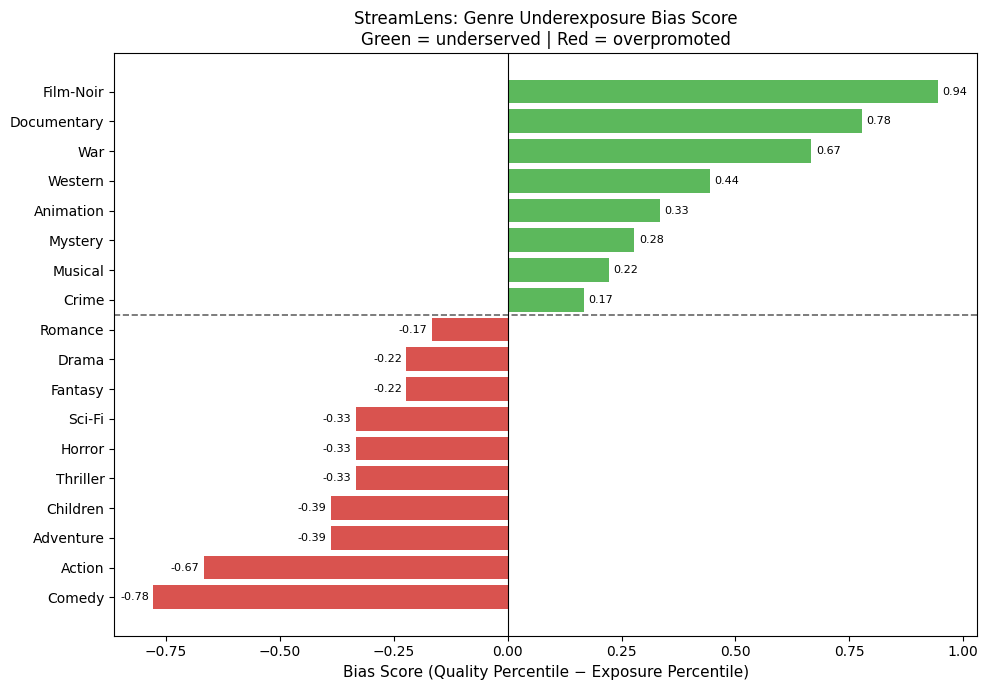

In [62]:
# Step 5: Bias Score Bar Chart
# Sort by bias_score so the chart reads from most underserved to most overpromoted
bias_sorted = genre_summary.sort_values('bias_score', ascending=True)

# Color each bar based on whether the genre is underserved or overpromoted
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in bias_sorted['bias_score']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(bias_sorted['genres'], bias_sorted['bias_score'], color=colors)

# Reference line at 0
ax.axvline(0, color='black', linewidth=0.8)

# Divider line between negative and near-zero bias scores
# Drawn at y=9.5, between Drama (y=9) and Crime (y=10)
ax.axhline(
    y=9.5,
    color='black',
    linewidth=1.2,
    linestyle='--',
    alpha=0.6
)

ax.set_xlabel('Bias Score (Quality Percentile − Exposure Percentile)', fontsize=11)
ax.set_title('StreamLens: Genre Underexposure Bias Score\n'
             'Green = underserved | Red = overpromoted', fontsize=12)

# Add value labels on each bar
for bar, val in zip(bars, bias_sorted['bias_score']):
    ax.text(
        val + 0.01 if val >= 0 else val - 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=8
    )

plt.tight_layout()
plt.savefig('../outputs/figures/phase2_bias_score.png', dpi=300, bbox_inches='tight')
plt.show()


## Phase 2 Summary -- Key Findings
1. **Bias Score**: 
    - **Overpromoted**: 
        Comedy (−0.78), Action (−0.67), and Adventure (−0.39) receive far more exposure than their quality ranking justifies.
    - **Underserved**: 
        Film-Noir (0.94), Documentary (0.78), and War (0.67) are the most underserved genres — highest quality ranks but lowest exposure ranks.

2. **Correlation**: Pearson r = −0.266 between `avg_rating` and `rating_count`, 
   indicating a moderate negative relationship — higher quality genres 
   systematically receive lower platform exposure.

3. **Visualization**: Quadrant plot confirms the structural pattern; 
   bias score chart provides an explicit ranking for stakeholder communication.